In [8]:
import yfinance as yf
import pandas as pd
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [9]:

# 1. DATA HANDLER

class DataHandler:

    @staticmethod
    def get_data(risk_tickers, safe_ticker, start_date, end_date):
        print(f"Fetching data for {risk_tickers + [safe_ticker]}...")
        all_tickers = risk_tickers + [safe_ticker]

        raw_data = yf.download(all_tickers, start=start_date, end=end_date, auto_adjust=True)

        try:
            prices = raw_data['Close']
        except KeyError:
            # Fallback for older versions of yfinance
            prices = raw_data['Adj Close']

        prices = prices.ffill().dropna()

        returns = np.log(prices / prices.shift(1)).dropna()
        return prices, returns

In [10]:
# 2. OPTIMIZATION MODULE

class PortfolioOptimizers:

    @staticmethod
    def risk_parity(cov_matrix):

        num_assets = cov_matrix.shape[0]

        def risk_budget_objective(weights, cov_matrix):
            port_var = weights.T @ cov_matrix @ weights
            if port_var == 0: return 1e9

            marginal_risk = cov_matrix @ weights
            risk_contribution = weights * marginal_risk / port_var
            target_rc = np.ones(num_assets) / num_assets
            return np.sum(np.square(risk_contribution - target_rc))

        constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1.0})
        bounds = tuple((0.0, 1.0) for _ in range(num_assets))
        initial_guess = np.ones(num_assets) / num_assets

        result = minimize(risk_budget_objective, initial_guess, args=(cov_matrix,),
                          method='SLSQP', bounds=bounds, constraints=constraints)

        return result.x if result.success else initial_guess


In [11]:

# 3. BACKTESTING ENGINE MODULE

class BacktestEngine:

    def __init__(self, prices, returns, risk_tickers, safe_ticker,
                 sma_window=200, half_life=63, rebalance_freq='ME', tc_bps=10):
        self.prices = prices
        self.returns = returns
        self.risk_tickers = risk_tickers
        self.safe_ticker = safe_ticker
        self.sma_window = sma_window
        self.half_life = half_life
        self.tc = tc_bps / 10000

        # Calculate dynamic SMA based on parameter
        self.sma = self.prices.rolling(window=self.sma_window).mean().dropna()

        # Align dates after SMA dropna
        valid_dates = self.sma.index
        self.prices = self.prices.loc[valid_dates]
        self.returns = self.returns.loc[valid_dates]
        self.rebalance_dates = self.returns.resample(rebalance_freq).last().index

    def run(self, verbose=True):
        if verbose: print(f"Running Backtest (SMA: {self.sma_window}, Half-Life: {self.half_life})...")

        rp_only_returns_list = []
        final_returns_list = []
        all_assets = self.risk_tickers + [self.safe_ticker]

        for i in range(1, len(self.rebalance_dates)):
            current_date = self.rebalance_dates[i-1]
            next_date = self.rebalance_dates[i]

            # Align dates to trading calendar
            if current_date not in self.returns.index:
                current_date = self.returns.index[self.returns.index <= current_date][-1]
            if next_date not in self.returns.index:
                next_date = self.returns.index[self.returns.index <= next_date][-1]
            if current_date >= next_date: continue

            # Slice historical data
            hist_returns = self.returns.loc[:current_date, self.risk_tickers]
            if len(hist_returns) < self.half_life: continue

            # EWMA Covariance
            cov_est = hist_returns.ewm(halflife=self.half_life).cov().xs(
                hist_returns.index[-1], level=0) * 252

            # Risk Parity Base Weights
            base_rp_weights = PortfolioOptimizers.risk_parity(cov_est.values)

            # Trend Filter Overlay
            current_prices = self.prices.loc[current_date, self.risk_tickers]
            current_smas = self.sma.loc[current_date, self.risk_tickers]
            trend_signals = (current_prices > current_smas).astype(int).values

            # Adjusted weights and cash sweep
            adjusted_risk_weights = base_rp_weights * trend_signals
            cash_weight = 1.0 - np.sum(adjusted_risk_weights)

            # Create weight vectors
            rp_weights = pd.Series(index=all_assets, dtype=float).fillna(0)
            rp_weights[self.risk_tickers] = base_rp_weights

            final_weights = pd.Series(index=all_assets, dtype=float).fillna(0)
            final_weights[self.risk_tickers] = adjusted_risk_weights
            final_weights[self.safe_ticker] = cash_weight

            # Forward Returns Simulation
            period_returns = self.returns.loc[current_date:next_date, all_assets].iloc[1:].copy()

            port_ret_rp = period_returns.dot(rp_weights)
            port_ret_final = period_returns.dot(final_weights)

            rp_only_returns_list.append(port_ret_rp)
            final_returns_list.append(port_ret_final)

        return pd.concat(rp_only_returns_list), pd.concat(final_returns_list)



In [12]:

# 4. PERFORMANCE ATTRIBUTION MODULE

class PerformanceAttribution:

    def __init__(self, benchmark, rp_only, final_strat, risk_free_rate=0.02):
        self.returns = pd.DataFrame({
            '1. Benchmark (SPY)': benchmark,
            '2. Risk Parity Only': rp_only,
            '3. RP + Trend Overlay': final_strat
        }).dropna()
        self.rf = risk_free_rate

    def _calc_metrics(self, returns_series):
        cagr = (1 + returns_series).prod() ** (252 / len(returns_series)) - 1
        vol = returns_series.std() * np.sqrt(252)
        sharpe = (cagr - self.rf) / vol if vol != 0 else 0

        cum_ret = (1 + returns_series).cumprod()
        drawdown = (cum_ret / cum_ret.cummax()) - 1
        mdd = drawdown.min()
        calmar = cagr / abs(mdd) if mdd != 0 else 0

        return {'CAGR (%)': cagr * 100, 'Vol (%)': vol * 100, 'Sharpe': sharpe,
                'Max DD (%)': mdd * 100, 'Calmar': calmar}

    def generate(self):
        metrics_df = pd.DataFrame([self._calc_metrics(self.returns[col]) for col in self.returns.columns],
                                  index=self.returns.columns).round(2)

        print("\n" + "="*60)
        print("PERFORMANCE ATTRIBUTION TEAR SHEET")
        print("="*60)
        print(metrics_df.to_string())

        rp_alpha = metrics_df.loc['2. Risk Parity Only', 'CAGR (%)'] - metrics_df.loc['1. Benchmark (SPY)', 'CAGR (%)']
        trend_alpha = metrics_df.loc['3. RP + Trend Overlay', 'CAGR (%)'] - metrics_df.loc['2. Risk Parity Only', 'CAGR (%)']
        trend_prot = metrics_df.loc['2. Risk Parity Only', 'Max DD (%)'] - metrics_df.loc['3. RP + Trend Overlay', 'Max DD (%)']

        print("\n--- Value Add Breakdown ---")
        print(f"Allocation Alpha (RP vs Bench):   {rp_alpha:+.2f}%")
        print(f"Timing Alpha (Trend vs RP):       {trend_alpha:+.2f}%")
        print(f"Drawdown Protection (Trend vs RP):{abs(trend_prot):+.2f}%")
        print("="*60 + "\n")



In [13]:

# 5. SENSITIVITY ANALYSIS MODULE

class SensitivityAnalyzer:

    @staticmethod
    def run_grid(prices, returns, risk_tickers, safe_ticker, sma_list, hl_list):
        print("\nStarting Parameter Sensitivity Grid Search...")
        results_matrix = np.zeros((len(sma_list), len(hl_list)))

        for i, sma in enumerate(sma_list):
            for j, hl in enumerate(hl_list):
                engine = BacktestEngine(prices, returns, risk_tickers, safe_ticker,
                                        sma_window=sma, half_life=hl, tc_bps=10)
                _, final_ret = engine.run(verbose=False)

                # Calculate Sharpe
                cagr = (1 + final_ret).prod() ** (252 / len(final_ret)) - 1
                vol = final_ret.std() * np.sqrt(252)
                sharpe = (cagr - 0.02) / vol if vol > 0 else 0
                results_matrix[i, j] = sharpe

        # Plotting the Heatmap
        plt.figure(figsize=(8, 6))
        sns.heatmap(results_matrix, annot=True, fmt=".2f", cmap="YlGnBu",
                    xticklabels=hl_list, yticklabels=sma_list)
        plt.title('Parameter Sensitivity: Sharpe Ratio')
        plt.xlabel('EWMA Half-Life (Days)')
        plt.ylabel('SMA Trend Window (Days)')
        plt.show()


[*********************100%***********************]  5 of 5 completed

Fetching data for ['SPY', 'AGG', 'GLD', 'BTC-USD', 'BIL']...
Running Backtest (SMA: 200, Half-Life: 63)...



PERFORMANCE ATTRIBUTION TEAR SHEET
                       CAGR (%)  Vol (%)  Sharpe  Max DD (%)  Calmar
1. Benchmark (SPY)         6.23    17.61    0.24      -35.75    0.17
2. Risk Parity Only        2.30     9.38    0.03      -21.31    0.11
3. RP + Trend Overlay      4.48     4.51    0.55       -7.01    0.64

--- Value Add Breakdown ---
Allocation Alpha (RP vs Bench):   -3.93%
Timing Alpha (Trend vs RP):       +2.18%
Drawdown Protection (Trend vs RP):+14.30%


Starting Parameter Sensitivity Grid Search...


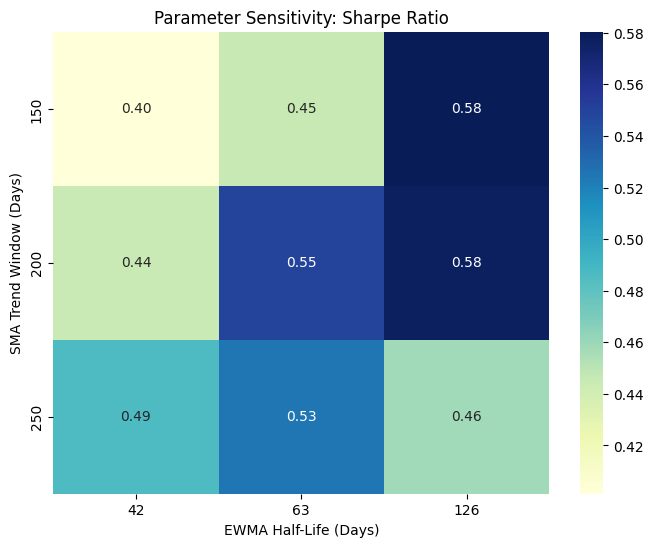

In [14]:


# 6. MAIN EXECUTION

if __name__ == "__main__":
    # 1. Define Universe
    risk_assets = ['SPY', 'AGG', 'GLD', 'BTC-USD']
    safe_asset = 'BIL'

    # 2. Fetch Data
    prices, returns = DataHandler.get_data(risk_assets, safe_asset, '2018-01-01', '2024-01-01')

    # 3. Run Standard Backtest (200-day SMA, 63-day Half-Life)
    engine = BacktestEngine(prices, returns, risk_assets, safe_asset, sma_window=200, half_life=63)
    rp_only_returns, final_returns = engine.run()

    # 4. Generate Performance Attribution
    benchmark = returns['SPY'].loc[final_returns.index]
    tear_sheet = PerformanceAttribution(benchmark, rp_only_returns, final_returns)
    tear_sheet.generate()

    # 5. Run Parameter Sensitivity Grid (Validating the parameters)
    sma_test_grid = [150, 200, 250]
    hl_test_grid = [42, 63, 126]

    SensitivityAnalyzer.run_grid(prices, returns, risk_assets, safe_asset, sma_test_grid, hl_test_grid)